### Extra featrues that we could create
avrage number of rounds per fight, maybe diff

* Physical advantage – reach + height − age (taller, longer, fresher).
* Striking pressure – sig-strike differential weighted toward the more active fighter.
* Grappling pressure – takedowns and sub attempts, where the difference is the threat, not the points.
* Experience gap – difference in total rounds + title bouts. A fighter who's been in five-round wars 8 times has a different gas tank than someone with 6 prelim minutes.
* Finish tendency – career KO + sub rate. Guys who finish create variance.
* Stance matchup – categorical, because Orthodox vs Southpaw is structurally different from Orthodox vs Orthodox.

In [89]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

data_frame = pd.read_csv("C:/Users/tumik/Documents/semester 5/machine learning/project1_repo/MachineLearningRepo/Project1/data/all_fights.csv")


# drop weird stances
data_frame = data_frame[~data_frame["blue_stance"].isin(["Switch ", "Open Stance", "Unknown"])]
data_frame = data_frame[~data_frame["red_stance"].isin(["Switch ", "Open Stance", "Unknown"])]


# dropping reach diff over 40 (1 entry)
data_frame = data_frame[(data_frame["reach_diff"] > -40) | (data_frame["reach_diff"] < 40)]


# dropping Catch Weight from weight_class
data_frame = data_frame[~data_frame["weight_class"].isin(["Catch Weight"])]


# Round_diff - check this one a bit better, only 1 super outlier
data_frame = data_frame[(data_frame["rounds_diff"] > -100) | (data_frame["rounds_diff"] < 100)]

# extra features list
extra_features = [
    "gender", "weight_class", "red_stance", "blue_stance", "red_age", "blue_age", "fight_date"
]


# ===================================== CREATING NEW FEATURES
print("===============")

#print(data_frame['stance_diff'].unique())

# total number of fights 
data_frame["red_total_fights"] = (data_frame["red_wins"] + data_frame["red_losses"])
data_frame["blue_total_fights"] = (data_frame["blue_wins"] + data_frame["blue_losses"])


# red_avg_number_rounds_per_fight
data_frame["red_avg_number_rounds_per_fight"] = round((data_frame["red_total_fights"]) / data_frame["red_total_rounds_fought"], 2)
data_frame = data_frame[(data_frame["red_avg_number_rounds_per_fight"] > 0) & (data_frame["red_avg_number_rounds_per_fight"] < 6)]
extra_features.append("red_avg_number_rounds_per_fight")

# blue_avg_number_rounds_per_fight
data_frame["blue_avg_number_rounds_per_fight"] = round((data_frame["blue_total_fights"]) / data_frame["blue_total_rounds_fought"], 2)
data_frame = data_frame[(data_frame["blue_avg_number_rounds_per_fight"] > 0) & (data_frame["blue_avg_number_rounds_per_fight"] < 6)]
extra_features.append("blue_avg_number_rounds_per_fight")

# diff_avg_rounds
data_frame["avg_rounds_diff"] = round(data_frame["red_avg_number_rounds_per_fight"] - data_frame["blue_avg_number_rounds_per_fight"], 2)



# Physical advantage – reach + height − age (taller, longer, fresher).
# blue_height_cms
# blue_reach_cms
# blue_age

# 
data_frame["red_physical_advantage"] = round(data_frame["red_height_cms"] + data_frame["red_reach_cms"] + data_frame["red_age"], 2)
#
data_frame["blue_physical_advantage"] = round(data_frame["blue_height_cms"] + data_frame["blue_reach_cms"] + data_frame["blue_age"], 2)
# 
data_frame["physical_advantage_diff"] = round(data_frame["red_physical_advantage"] + data_frame["blue_physical_advantage"], 2)

#print(test_frame.loc[1]["red_avg_number_rounds_per_fight"])
#print(test_frame['red_avg_number_rounds_per_fight'].unique())

print("===============")
#NOTE: extra  features
# - red_avg_number_rounds_per_fight
# - blue_avg_number_rounds_per_fight
# ===================================== CREATING NEW FEATURES


# getting all features with diff 
diff_features_df = data_frame.filter(regex=r'_diff')

#TODO: Other attributes than diff that we will keep
extra_features_df = data_frame[extra_features]

feature_selected_df = pd.concat([extra_features_df, diff_features_df], axis=1)

#NOTE: maybe no buckets
# adding age buckets
bins = [17, 23, 27, 33, float("inf")]
labels = ["18-23", "24-27", "28-33", "34+"]

feature_selected_df["red_age_bucket"] = pd.cut(
    data_frame["red_age"],
    bins=bins,
    labels=labels
)

feature_selected_df["blue_age_bucket"] = pd.cut(
    data_frame["blue_age"],
    bins=bins,
    labels=labels
)


# drop red_ and blue_age
feature_selected_df = feature_selected_df.drop(columns=['red_age'])
feature_selected_df = feature_selected_df.drop(columns=['blue_age'])
# drop odds_diff
feature_selected_df = feature_selected_df.drop(columns=['odds_diff'])

# ============================================================================================== SPLIT
#NOTE: class variable??
class_df = data_frame[["red_winner","fight_date"]]


#NOTE: split the data based on fight date
DATE = "2023-06-01"
SPLIT_DATE = r"2023-06-01"

# splitting the data thing
x_train_OG = feature_selected_df.loc[feature_selected_df['fight_date'] <= SPLIT_DATE]
x_test_OG  = feature_selected_df.loc[feature_selected_df['fight_date'] > SPLIT_DATE]

# drop fight_date
x_train_OG = x_train_OG.drop(columns=['fight_date'])
x_test_OG = x_test_OG.drop(columns=['fight_date'])

# splitting the class thing
y_train_OG = class_df.loc[class_df['fight_date'] <= SPLIT_DATE]
y_test_OG  = class_df.loc[class_df['fight_date'] > SPLIT_DATE]

# drop fight_date
y_train_OG = y_train_OG.drop(columns=['fight_date'])
y_test_OG = y_test_OG.drop(columns=['fight_date'])

#x_train.info()

### Good Combos

62% 
* {'clf__colsample_bytree': 0.5, 'clf__learning_rate': 0.01, 'clf__max_depth': 3, 'clf__n_estimators': 500, 'clf__subsample': 0.5}

62%
* {'clf__colsample_bytree': 0.5, 'clf__gamma': 5, 'clf__learning_rate': 0.01, 'clf__max_depth': 6, 'clf__min_child_weight': 20, 'clf__n_estimators': 500, 'clf__subsample': 0.5}

62.8%
* {'clf__colsample_bytree': 0.5, 'clf__gamma': 5, 'clf__learning_rate': 0.01, 'clf__max_depth': 3, 'clf__min_child_weight': 20, 'clf__n_estimators': 500, 'clf__subsample': 0.3}

63%
with physical_advantage_diff and avg_round_diff

Best parameters:
{'clf__colsample_bytree': 0.5, 'clf__gamma': 0, 'clf__learning_rate': 0.01, 'clf__max_depth': 3, 'clf__min_child_weight': 20, 'clf__n_estimators': 300, 'clf__subsample': 0.3}

Best cross-validation ROC-AUC:
0.6305541866618013
Training score: 0.6779588329152902
Validation score: 0.6305541866618013
0.5978494623655914
              precision    recall  f1-score   support

           0       0.59      0.33      0.43       623
           1       0.60      0.81      0.69       772

    accuracy                           0.60      1395
   macro avg       0.59      0.57      0.56      1395
weighted avg       0.60      0.60      0.57      1395

================== Feature Importance ==================
                           feature  importance
0                    num__age_diff    0.057617
41         cat__red_age_bucket_34+    0.054875
30  cat__weight_class_Middleweight    0.043504
37                cat__gender_MALE    0.043442
43      cat__blue_age_bucket_24-27    0.038113


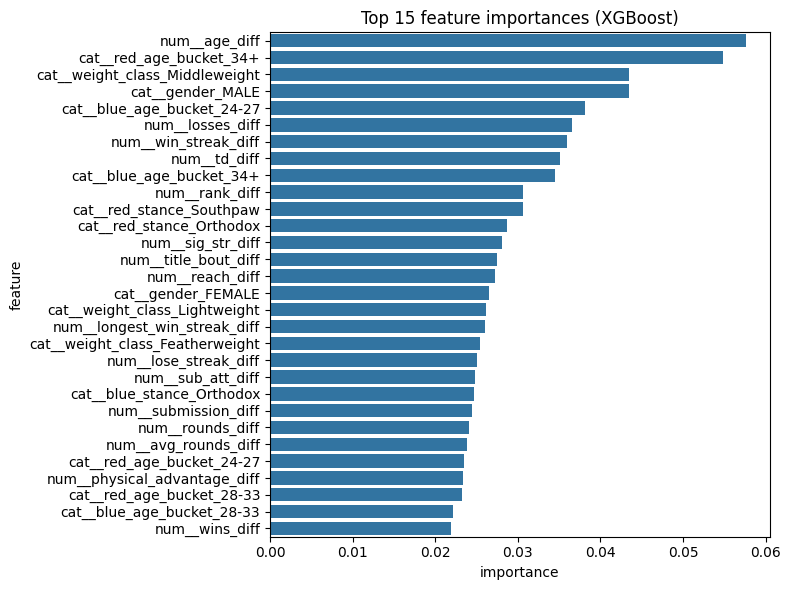

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report


x_train = x_train_OG
x_test = x_test_OG


le = LabelEncoder()
y_train = le.fit_transform(y_train_OG["red_winner"])
y_test = le.transform(y_test_OG["red_winner"])


#NOTE: always need to add new features here
categorical_features = ["red_stance", "blue_stance", "weight_class", "gender", "red_age_bucket", "blue_age_bucket"]
numeric_features = [
    "age_diff", "td_diff", "sig_str_diff", "reach_diff", "losses_diff",
    "sub_att_diff", "rank_diff",
    "win_streak_diff", "longest_win_streak_diff", "lose_streak_diff",
    "title_bout_diff", "wins_diff", "rounds_diff", "height_diff",
    "ko_diff", "submission_diff", "avg_rounds_diff", "physical_advantage_diff"
]


preprocessor = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), numeric_features),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features)
])

pipeline_xgb = Pipeline([
    ("preprocess", preprocessor),
    ("clf", XGBClassifier(
        eval_metric="logloss",
        random_state=42
    ))
])

pipeline_xgb.fit(x_train, y_train)
y_predicted = pipeline_xgb.predict(x_test)

# XGBOOST hyper parameters
param_grid = {
    "clf__n_estimators": [300, 500],
    "clf__max_depth": [3, 6],
    "clf__learning_rate": [0.01, 0.1],
    "clf__subsample": [0.3, 0.5],
    "clf__colsample_bytree": [0.5],
    "clf__min_child_weight": [10, 20],
    "clf__gamma": [0, 3, 5],
}


grid_search = GridSearchCV(
    pipeline_xgb,
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    return_train_score=True
)

grid_search.fit(x_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)
print()
print("Best cross-validation ROC-AUC:")
print(grid_search.best_score_)

best_index = grid_search.best_index_
print("Training score:", grid_search.cv_results_["mean_train_score"][best_index])
print("Validation score:", grid_search.cv_results_["mean_test_score"][best_index])


best_model = grid_search.best_estimator_
xgb_clf = best_model.named_steps["clf"]

# Get feature names after one-hot encoding
feature_names = best_model.named_steps["preprocess"].get_feature_names_out()

importances = xgb_clf.feature_importances_
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

preds = best_model.predict(x_test)

print()
print(accuracy_score(y_test, preds))
print(classification_report(y_test, preds))

print("================== Feature Importance ==================")
print(importance_df.head(15))

plt.figure(figsize=(8, 6))
sns.barplot(data=importance_df.head(30), x="importance", y="feature")
plt.title("Top 15 feature importances (XGBoost)")
plt.tight_layout()
plt.show()